# **Resimlerin Karşılaştırılması**

####**Bu derste şunları öğreneceğiz:**
1. Ortalama Karesel Hata (MSE) kullanarak Görüntüleri Karşılaştırma
2. Yapısal Benzerlik Kullanarak Görüntüleri Karşılaştırma

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import structural_similarity

def imshow(title = "Image", image = None, size = 8):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

#### ** Ortalama Karesel Hata (MSE)**

İki görüntü arasındaki MSE, iki görüntü arasındaki karesel farkın toplamıdır. Bu, numpy ile kolayca uygulanabilir.

MSE ne kadar düşükse görüntüler o kadar benzerdir.

In [2]:
def mse(image1, image2):
	# Görüntüler aynı boyutta olmalıdır
	error = np.sum((image1.astype("float") - image2.astype("float")) ** 2)
	error /= float(image1.shape[0] * image1.shape[1])

	return error

#### **3 Resim alalım**

1. Fireworks1 
2. Fireworks1 parlaklığı arttırılmış
3. Fireworks2

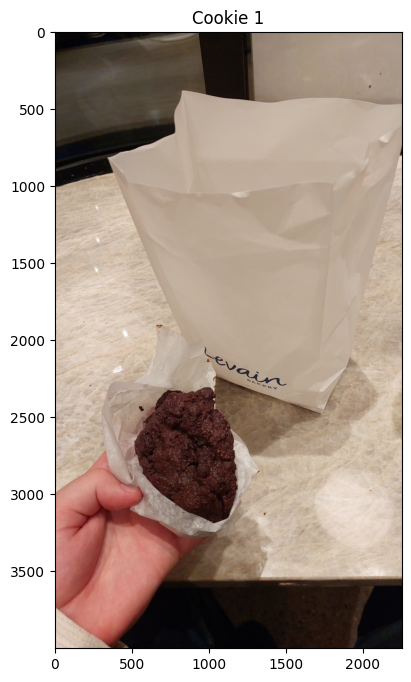

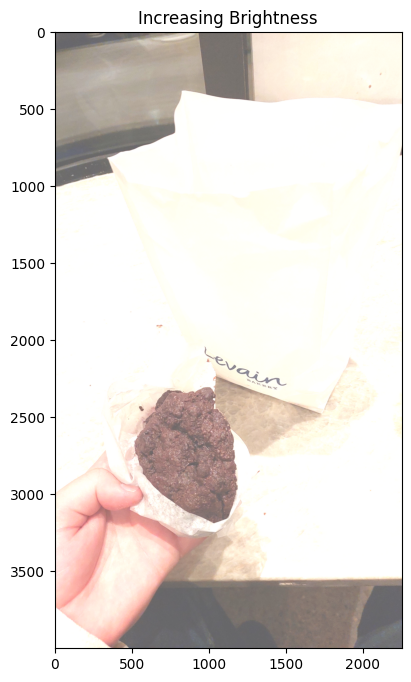

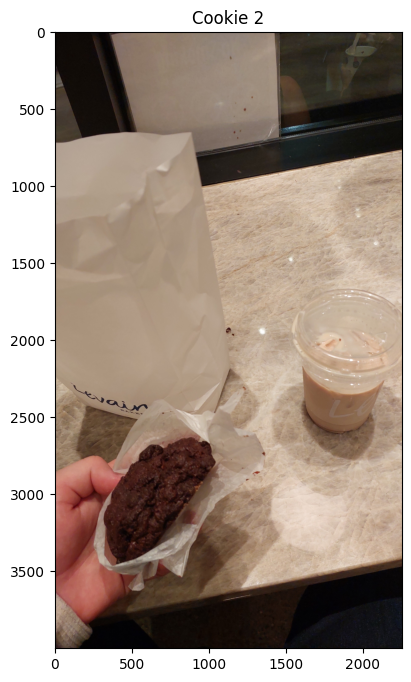

In [5]:
fireworks1 = cv2.imread('../files/images/america27.jpg')
fireworks2 = cv2.imread('../files/images/america28.jpg')

M = np.ones(fireworks1.shape, dtype = "uint8") * 100 
fireworks1b = cv2.add(fireworks1, M)

imshow("Cookie 1", fireworks1)
imshow("Increasing Brightness", fireworks1b)
imshow("Cookie 2", fireworks2)

In [6]:
def compare(image1, image2):
  image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
  image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
  print('MSE = {:.2f}'.format(mse(image1, image2)))
  print('SS = {:.2f}'.format(structural_similarity(image1, image2)))
#structural_similarity(image1, image2) fonksiyonu, iki görüntü arasındaki yapısal benzerliği (SSIM) hesaplar.
# Kullanım score, diff = ssim(image1, image2, full=True)
# Parametreler
# image1 → Karşılaştırılacak ilk görüntü (gri tonlama veya renkli).
# image2 → Karşılaştırılacak ikinci görüntü (aynı boyutta olmalı).
# full=True  ise → Fark görüntüsünü de döndürür (iki görüntü arasındaki farkı gösterir).

In [7]:
# Aynı olduklarında
compare(fireworks1, fireworks1)

MSE = 0.00
SS = 1.00


In [8]:
compare(fireworks1, fireworks2)

MSE = 4278.52
SS = 0.56


In [9]:
compare(fireworks1, fireworks1b)

MSE = 7116.70
SS = 0.73


In [10]:
compare(fireworks2, fireworks1b)

MSE = 13296.54
SS = 0.57
